### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [4]:
# Examine column data types and non-null counts
data.info()

# Count number or entries
numEntries = len(data)
print('\nNumber of entries    = ', numEntries)

# look for duplicate entries
numDuplicates = data.duplicated().sum()
print('\nNumber of duplicates = ', numDuplicates)

# Calculate percentage of missing data
pctMissing = data.isna().sum() / numEntries * 100
print('\nPercent missing data\n')
print(pctMissing)



<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

3. Decide what to do about your missing data -- drop, replace, other...

In [5]:
# Drop car column since > 99% of the data is missing
# This needs to be done before dropping all rows with missing data
# Then drop all rows with missing data 
# Valid since no one column is missing more that 2% of data
# Reset index with drop=True to renumber 1 to N without any missing value

dataCleaned = data.drop(['car'], axis=1).dropna().reset_index(drop=True)

# examine data information to verify all entries contain only non-null data
dataCleaned.info()

# determine percentage of entries dropped
pctDropped =  (1 - len(dataCleaned) / len(data)) * 100
print(f'\nPercent dropped = {pctDropped:.2f}%')

dataCleaned.head()

<class 'pandas.DataFrame'>
RangeIndex: 12079 entries, 0 to 12078
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12079 non-null  str  
 1   passanger             12079 non-null  str  
 2   weather               12079 non-null  str  
 3   temperature           12079 non-null  int64
 4   time                  12079 non-null  str  
 5   coupon                12079 non-null  str  
 6   expiration            12079 non-null  str  
 7   gender                12079 non-null  str  
 8   age                   12079 non-null  str  
 9   maritalStatus         12079 non-null  str  
 10  has_children          12079 non-null  int64
 11  education             12079 non-null  str  
 12  occupation            12079 non-null  str  
 13  income                12079 non-null  str  
 14  Bar                   12079 non-null  str  
 15  CoffeeHouse           12079 non-null  str  
 16  CarryAway      

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,21,Single,...,less1,4~8,4~8,less1,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,0


4. What proportion of the total observations chose to accept the coupon?



In [6]:
# Calculated percent accepted by taking mean value of Y column
# This works since Y = 1 for "yes", Y = 0 for "no"

pctAccepted = dataCleaned['Y'].mean() * 100

print(f"\nPercent accepted = {pctAccepted:.1f}%")


Percent accepted = 56.9%


5. Use a bar plot to visualize the `coupon` column.

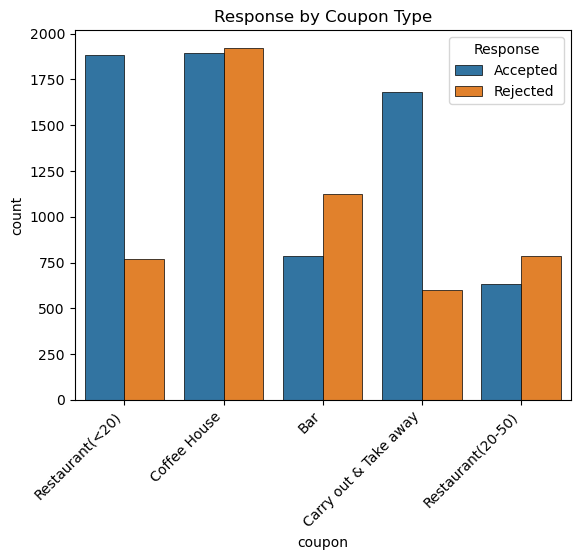

In [7]:
# create new column "Response" for more meaninful legend
# mapping 0 = "Rejected" and 1 = "Accepted"
dataCleaned['Response'] = dataCleaned['Y'].map({0: 'Rejected', 1: 'Accepted'})

sns.countplot(data=dataCleaned, x='coupon', hue='Response', edgecolor='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.title('Response by Coupon Type')
plt.show()

coupon
Bar                      0.411918
Restaurant(20-50)        0.446013
Coffee House             0.496331
Restaurant(<20)          0.709009
Carry out & Take away    0.737719
Name: Y, dtype: float64


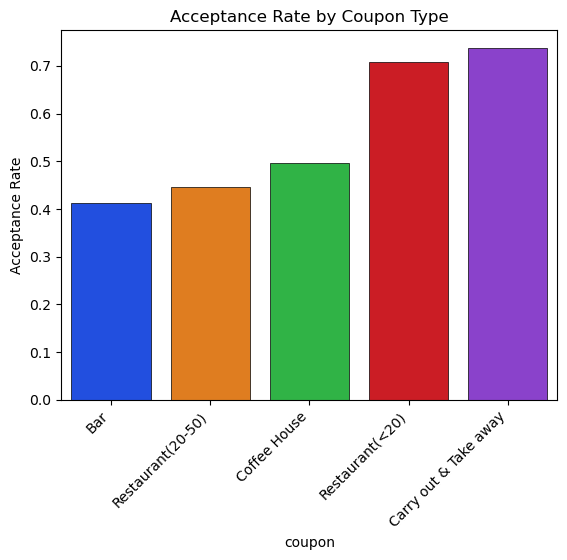

In [8]:
# check for plot accuracy by computing the acceptance rate by coupon type
acceptanceRate = dataCleaned.groupby('coupon')['Y'].mean().sort_values()
print(acceptanceRate)

# Make a bar plot of the acceptance rate as well
sns.barplot(x=acceptanceRate.index, y=acceptanceRate.values, 
            hue=acceptanceRate.index, palette='bright', legend=False,
            edgecolor='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Acceptance Rate')
plt.title('Acceptance Rate by Coupon Type')
plt.show()

6. Use a histogram to visualize the temperature column.

3


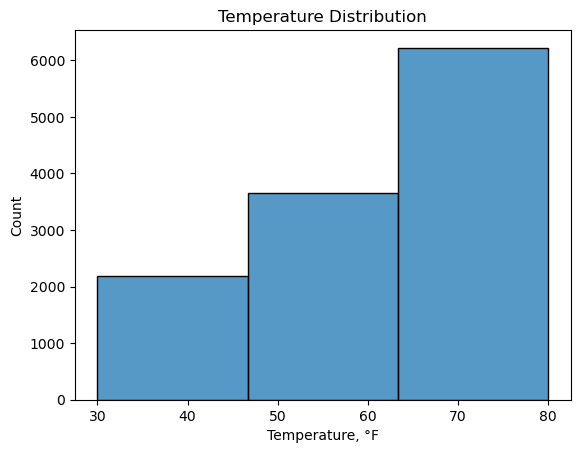

In [9]:
# Not a very interesting histogram since there are only 3 unique values
# most observations occur at higher temperatures

print(len(dataCleaned['temperature'].unique()))

sns.histplot(data=dataCleaned, x='temperature', bins=3)
plt.xlabel('Temperature, °F')
plt.title('Temperature Distribution')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [10]:
dfBar = dataCleaned[dataCleaned['coupon'] == 'Bar']
dfBar.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y,Response
2,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,1,Accepted
13,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,1,0,1,Accepted
17,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,4~8,4~8,less1,1,1,1,0,1,1,Accepted
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,1~3,1~3,never,1,0,0,0,1,0,Rejected
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,1~3,1~3,never,1,0,0,1,0,0,Rejected


2. What proportion of bar coupons were accepted?


In [11]:
pctBarAccepted = dfBar['Y'].mean() * 100

print(f"\nBar coupons accepted = {pctBarAccepted:.1f}%")


Bar coupons accepted = 41.2%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [12]:
threeOrLess = dfBar[dfBar['Bar'].isin(['never', 'less1', '1~3'])]['Y'].mean() * 100
moreThanThree = dfBar[dfBar['Bar'].isin(['4~8', 'gt8'])]['Y'].mean() * 100


print('\nBar coupon acceptance rate by monthly visit frequency')
print(f'\n\tThree times or less: {threeOrLess:.1f}%')
print(f'\n\tGreater than three:  {moreThanThree:.1f}%')

ratio = moreThanThree / threeOrLess

print(f'\nThose that go to bar more than 3 times per month are ~{ratio:.1f} times more likely to accept coupon.\n')



Bar coupon acceptance rate by monthly visit frequency

	Three times or less: 37.3%

	Greater than three:  76.2%

Those that go to bar more than 3 times per month are ~2.0 times more likely to accept coupon.



4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [13]:
# Note: 'more than once a month' is ambiguous between 'less1' and '1~3'
# for the purpose of this exercise I am treating '1-3' as 'more than once a month'

lessThanOne = ['never', 'less1']
lessThan25 = ['below21', '21']

# create a 'target group' mask for those NOT in the lessThanOne AND lessThan25 groups
# 'all others' are those NOT in the target group as defined by the mask

mask = ~(dfBar['Bar'].isin(lessThanOne)) & ~(dfBar['age'].isin(lessThan25))

targetRate = dfBar[mask]['Y'].mean() * 100
othersRate = dfBar[~mask]['Y'].mean() * 100

print('\nTarget Group Acceptance Rate versus All Others')
print(f'\n\tTarget Group: {targetRate:.1f}%')
print(f'\n\tAll Others:   {othersRate:.1f}%')



Target Group Acceptance Rate versus All Others

	Target Group: 69.0%

	All Others:   33.8%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [14]:
# To simplify the code, and logic, 
# I am going to create a mask of all those in target group
# Note: passenger is spelled incorrectly, as 'passanger'

mask = (
    (dfBar['Bar'].isin(['1~3', '4~8', 'gt8'])) 
    & ~(dfBar['passanger'].isin(['Kid(s)'])) 
    & ~(dfBar['occupation'].isin(['Farming Fishing & Forestry']))
)

targetRate = dfBar[mask]['Y'].mean() * 100
othersRate = dfBar[~mask]['Y'].mean() * 100

print('\nTarget Group Acceptance Rate versus All Others')
print(f'\n\tTarget Group: {targetRate:.1f}%')
print(f'\n\tAll Others:   {othersRate:.1f}%')


Target Group Acceptance Rate versus All Others

	Target Group: 70.9%

	All Others:   29.8%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [15]:
# Assuming that the 'more than 4 times" group includes those in '4~8'

# Split into 3 separate masks for readability

mask1 = (
     (dfBar['Bar'].isin(['1~3', '4~8', 'gt8'])) 
    & ~(dfBar['passanger'].isin(['Kid(s)'])) 
    & ~(dfBar['maritalStatus'].isin(['Widowed']))
)

mask2 = (
     (dfBar['Bar'].isin(['1~3', '4~8', 'gt8'])) 
    & (dfBar['age'].isin(['below21', '21', '26'])) 
)

lessThan50K = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']

mask3 = (
     (dfBar['RestaurantLessThan20'].isin(['4~8', 'gt8'])) 
    & (dfBar['income'].isin(lessThan50K)) 
)

# OR all three masks per problem statement
mask = mask1 | mask2 | mask3

targetRate = dfBar[mask]['Y'].mean() * 100
othersRate = dfBar[~mask]['Y'].mean() * 100

print('\nTarget Group Acceptance Rate versus All Others')
print(f'\n\tTarget Group: {targetRate:.1f}%')
print(f'\n\tAll Others:   {othersRate:.1f}%')


Target Group Acceptance Rate versus All Others

	Target Group: 58.7%

	All Others:   30.0%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

The acceptance rate of bar coupons appears to be primarily driven by how often a driver visits a bar each month. Drivers who go to a bar more than 3 times per month accepted the coupon about 76% of the time, compared to roughly 37% for those who went less often - a rate nearly twice as high (see Problem 3). Other factors, such as age, income, marital status, appear to have a secondary effect as adding these conditions on top of frequent bar attendance did little to raise the acceptance rate beyond what bar-frequency alone would have predicted (see Problems 4 & 5). This is reinforced in Problem 6, where broadening the target group to include drivers who were not frequent bar-goers lowered the acceptance rate to about 59%.



### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  



In [16]:
# Create a new DataFrame that contains just the expensive restaurant coupons

dfExpRest = dataCleaned[dataCleaned['coupon'] == 'Restaurant(20-50)']
dfExpRest.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y,Response
14,Home,Alone,Sunny,55,6PM,Restaurant(20-50),1d,Male,21,Single,...,4~8,4~8,less1,1,1,0,0,1,0,Rejected
18,Work,Alone,Sunny,80,7AM,Restaurant(20-50),1d,Male,21,Single,...,4~8,4~8,less1,1,1,0,0,1,0,Rejected
36,Home,Alone,Sunny,55,6PM,Restaurant(20-50),1d,Male,46,Single,...,1~3,1~3,never,1,1,0,0,1,0,Rejected
40,Work,Alone,Sunny,80,7AM,Restaurant(20-50),1d,Male,46,Single,...,1~3,1~3,never,1,1,0,0,1,0,Rejected
58,Home,Alone,Sunny,55,6PM,Restaurant(20-50),1d,Male,46,Married partner,...,1~3,1~3,less1,1,1,0,0,1,0,Rejected


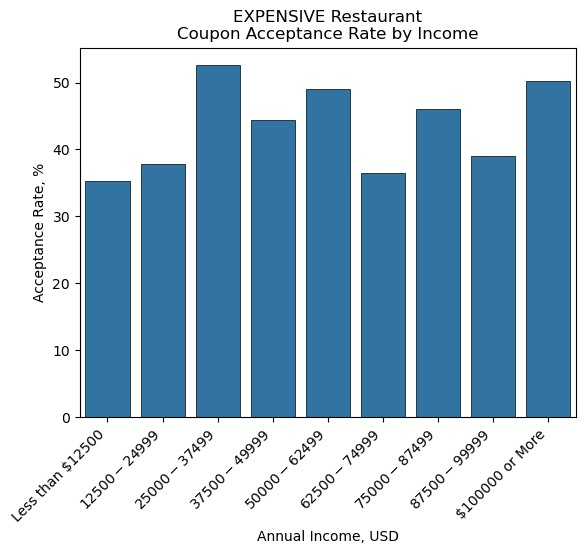

In [17]:
# bar plot of expensive restaurant coupon acceptance by income

# Create series of income brackets from lowest to highest
incomeOrder = ['Less than $12500', '$12500 - $24999', '$25000 - $37499',
               '$37500 - $49999', '$50000 - $62499', '$62500 - $74999',
               '$75000 - $87499', '$87500 - $99999', '$100000 or More']

# group by income bracket and calculate the acceptance rate
acceptanceRate = dfExpRest.groupby('income')['Y'].mean() * 100

# Reindex based on income brackets from lowest to highest
acceptanceRate = acceptanceRate.reindex(incomeOrder)

# Make a bar plot of the acceptance rate by income bracket
sns.barplot(x=acceptanceRate.index, y=acceptanceRate.values,  edgecolor='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Annual Income, USD')
plt.ylabel('Acceptance Rate, %')
plt.title('EXPENSIVE Restaurant\nCoupon Acceptance Rate by Income')
plt.show()

In [18]:
# Create a new DataFrame that contains just the cheap restaurant coupons

dfChpRest = dataCleaned[dataCleaned['coupon'] == 'Restaurant(<20)']
dfChpRest.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y,Response
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,1,Accepted
7,No Urgent Place,Friend(s),Sunny,80,2PM,Restaurant(<20),1d,Male,21,Single,...,4~8,4~8,less1,1,1,0,0,1,1,Accepted
9,No Urgent Place,Friend(s),Sunny,80,6PM,Restaurant(<20),2h,Male,21,Single,...,4~8,4~8,less1,1,1,0,0,1,1,Accepted
20,Work,Alone,Sunny,55,7AM,Restaurant(<20),1d,Male,21,Single,...,4~8,4~8,less1,1,0,0,0,1,1,Accepted
22,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,46,Single,...,1~3,1~3,never,1,0,0,0,1,1,Accepted


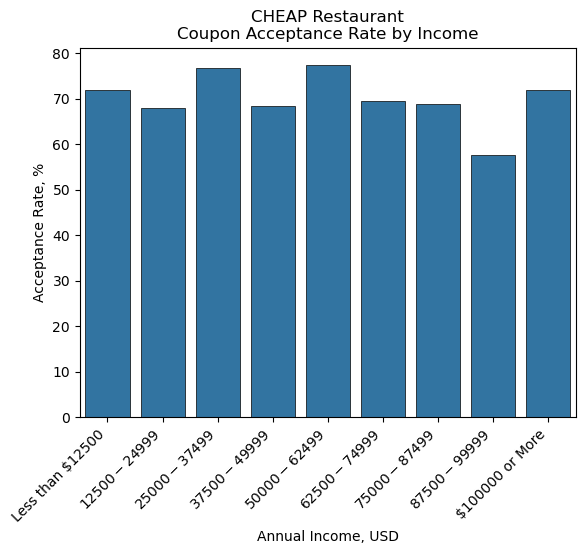

In [19]:
# bar plot of cheap restaurant coupon acceptance by income

# Create series of income brackets from lowest to highest
incomeOrder = ['Less than $12500', '$12500 - $24999', '$25000 - $37499',
               '$37500 - $49999', '$50000 - $62499', '$62500 - $74999',
               '$75000 - $87499', '$87500 - $99999', '$100000 or More']

# group by income bracket and calculate the acceptance rate
acceptanceRate = dfChpRest.groupby('income')['Y'].mean() * 100

# Reindex based on income brackets from lowest to highest
acceptanceRate = acceptanceRate.reindex(incomeOrder)

# Make a bar plot of the acceptance rate by income bracket
sns.barplot(x=acceptanceRate.index, y=acceptanceRate.values,  edgecolor='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Annual Income, USD')
plt.ylabel('Acceptance Rate, %')
plt.title('CHEAP Restaurant\nCoupon Acceptance Rate by Income')
plt.show()

Acceptance of neither expensive nor cheap restaurant coupons appears to be driven by income level. So, what does drive restaurant coupon acceptance?

In [20]:
print('\nSpread in acceptance rate by category for cheap restaurant coupons\n')

for col in ['passanger', 'time', 'destination', 'weather', 'expiration',
            'gender', 'age', 'maritalStatus', 'has_children',
            'RestaurantLessThan20', 'income', 'education']:
    
    # compute rates for each category (column) selected
    rates = dfChpRest.groupby(col)['Y'].mean() * 100
    
    # compute spread in exceptance rates by category
    spread = (rates.max() - rates.min())
    print(f'\t{col:22} {spread:5.1f}%')



Spread in acceptance rate by category for cheap restaurant coupons

	passanger               16.3%
	time                    31.9%
	destination             23.7%
	weather                 37.5%
	expiration              24.7%
	gender                   2.2%
	age                     11.1%
	maritalStatus           21.1%
	has_children             2.5%
	RestaurantLessThan20    13.3%
	income                  19.7%
	education               12.4%


The top three categories that appear to drive accpeptance rate are, in order, weather, time and expiration. Let's explore those driver a bit more.

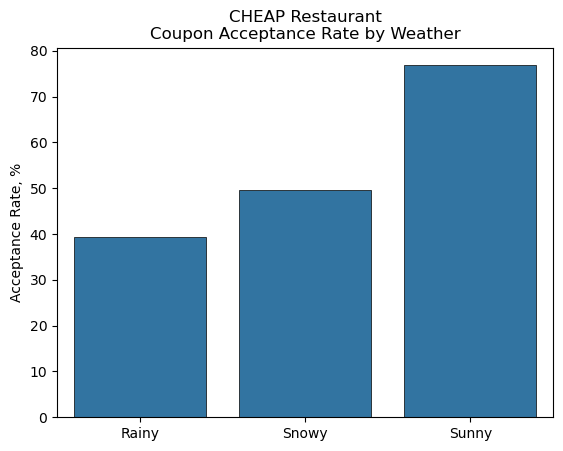

In [21]:
# bar plot of cheap restaurant coupon acceptance by weather

# group by weather and calculate the acceptance rate
acceptanceRate = dfChpRest.groupby('weather')['Y'].mean() * 100

# Make a bar plot of the acceptance rate by weather
sns.barplot(x=acceptanceRate.index, y=acceptanceRate.values,  edgecolor='black', linewidth=0.5)
plt.xlabel('')
plt.ylabel('Acceptance Rate, %')
plt.title('CHEAP Restaurant\nCoupon Acceptance Rate by Weather')
plt.show()

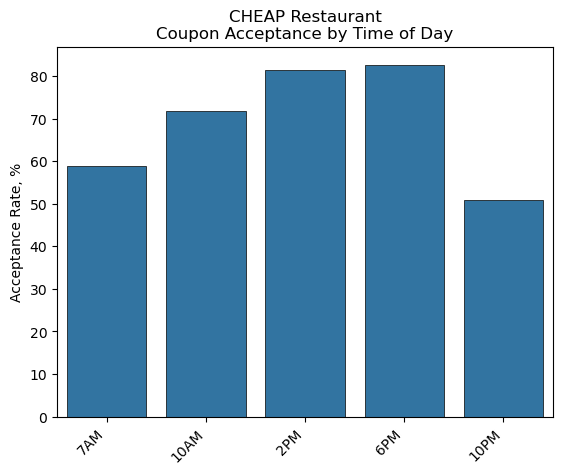

In [22]:
# bar plot of cheap restaurant coupon acceptance by time

# Create series of times brackets from earliest to latest 
timeOrder = ['7AM', '10AM', '2PM', '6PM', '10PM']

# group by time and calculate the acceptance rate
acceptanceRate = dfChpRest.groupby('time')['Y'].mean() * 100

# Reindex based on income brackets from lowest to highest
acceptanceRate = acceptanceRate.reindex(timeOrder)

# Make a bar plot of the acceptance rate by income bracket
sns.barplot(x=acceptanceRate.index, y=acceptanceRate.values,  edgecolor='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.xlabel('')
plt.ylabel('Acceptance Rate, %')
plt.title('CHEAP Restaurant\nCoupon Acceptance by Time of Day')
plt.show()

No need to plot results for expiration time since there are only two categories, 2 hours and 1 day, let's see which one has the highest acceptance rate.

In [23]:
rate2h = dfChpRest[dfChpRest['expiration'].isin(['2h'])]['Y'].mean() * 100
rate1d = dfChpRest[dfChpRest['expiration'].isin(['1d'])]['Y'].mean() * 100

print('\nCHEAP Restaurant\nCoupon Acceptance Rate by Expiration')
print(f'\n\t2 Hours: {rate2h:.1f}%')
print(f'\t1 Day:   {rate1d:.1f}%')



CHEAP Restaurant
Coupon Acceptance Rate by Expiration

	2 Hours: 58.9%
	1 Day:   83.6%


So, it would appear that the highest accptance rate for cheap restaurant coupons is on sunny days, in the late afternoon, and when then expiration date is 1d (instead of 2h).  Next, lets see if all three of these conditions compound to provide an even higher acceptance rate...

In [24]:
mask = (
     (dfChpRest['weather'].isin(['Sunny'])) 
    & (dfChpRest['time'].isin(['2PM', '6PM'])) 
    & (dfChpRest['expiration'].isin(['1d']))
)

targetRate = dfChpRest[mask]['Y'].mean() * 100
othersRate = dfChpRest[~mask]['Y'].mean() * 100

print('\nTarget Group Acceptance Rate versus All Others')
print(f'\n\tTarget Group: {targetRate:.1f}%')
print(f'\n\tAll Others:   {othersRate:.1f}%')


Target Group Acceptance Rate versus All Others

	Target Group: 90.0%

	All Others:   64.8%


Indeed, the acceptance rate when you combine all three conditions (sunny, afternoon and 1d-expiration) is 90%, compared around 65% to all other situations.  Let's check the size of the target group next to verify this is a stastically relevant sample size.

In [25]:
print(len(dfChpRest[mask]), len(dfChpRest))


639 2653


Yes, a sample size of 639 should be statistically relevant. Now, let's see if this holds true for expensive restaurants

In [26]:
mask = (
     (dfExpRest['weather'].isin(['Sunny'])) 
    & (dfExpRest['time'].isin(['2PM', '6PM'])) 
    & (dfExpRest['expiration'].isin(['1d']))
)

targetRate = dfExpRest[mask]['Y'].mean() * 100
othersRate = dfExpRest[~mask]['Y'].mean() * 100

print('\nTarget Group Acceptance Rate versus All Others')
print(f'\n\tTarget Group: {targetRate:.1f}%')
print(f'\n\tAll Others:   {othersRate:.1f}%')


Target Group Acceptance Rate versus All Others

	Target Group: 55.5%

	All Others:   40.6%


So, while it is a driver for expensive restaurants at 56% vs 41%, it does not nearly have the same impact as it does for cheap restaurant coupons.

In [27]:
print('\nSpread in acceptance rate by category for all coupons\n')

for col in ['passanger', 'time', 'destination', 'weather', 'expiration',
            'gender', 'age', 'maritalStatus', 'has_children',
            'RestaurantLessThan20', 'income', 'education']:
    
    # compute rates for each category (column) selected
    rates = dataCleaned.groupby(col)['Y'].mean() * 100
    
    # compute spread in exceptance rates by category
    spread = (rates.max() - rates.min())
    print(f'\t{col:22} {spread:5.1f}%')


Spread in acceptance rate by category for all coupons

	passanger               18.0%
	time                    15.7%
	destination             13.0%
	weather                 13.3%
	expiration              13.3%
	gender                   4.5%
	age                     12.5%
	maritalStatus           13.8%
	has_children             4.9%
	RestaurantLessThan20     7.0%
	income                  10.5%
	education               18.9%


There doesn't appear to be as big of a driver across all coupon types.  Determining drivers should be done by individual coupon types.